In [1]:
import jax
import sys
original_sys_path = sys.path.copy()
sys.path.append('../')
from utils_visualization import *
import scqubits
import numpy as np
from scipy.optimize import minimize


import sys
sys.path.append('../')
from utils_models import *



n_evals = 25
def get_chi(Er,ql1,elements,evals):
    return sum([get_shift_accurate(elements[ql1,ql2], evals[ql2], evals[ql1], Er) for ql2 in range(n_evals)] )

jax_get_chi = jax.jit(jax.vmap(get_chi,in_axes = (0,None,None,None)))


def find_closest_transition(Er,evals):
    arr = np.array([evals[7]-evals[0],
                    evals[9]-evals[0],
                    evals[11]-evals[0],
                    evals[13]-evals[0]])
    names = ['07','09','011','013']
    differences = jnp.abs(arr - Er)
    closest_index = jnp.argmin(differences)
    return names[closest_index]

def get_transition(EJoverEL, EJoverEC):
    EJ = 4
    EL = EJ/EJoverEL
    EC = EJ/EJoverEC

    qbt = scqubits.Fluxonium(EJ = EJ,EC = EC,EL = EL, cutoff = 110,flux = 0,truncated_dim=n_evals)
    evals = qbt.eigenvals(n_evals)
    elements =  qbt.matrixelement_table(operator = "n_operator",evals_count=n_evals)
    Er_list = np.linspace(evals[6]-evals[0],   evals[12]-evals[0],   int(1e6))

    chi0 = jax_get_chi(Er_list,0,elements,evals)
    chi1 = jax_get_chi(Er_list,1,elements,evals)
    chi2 = jax_get_chi(Er_list,2,elements,evals)

    one_two_crossovers = np.nonzero(np.diff(np.sign(chi1[:] - chi2[:])))[0]
    results = []
    for crossover in one_two_crossovers:
        if jnp.all(jnp.abs(chi1[crossover-10:crossover+10] - chi2[crossover-10:crossover+10]) < 1e-5):
            results.append([  Er_list[crossover]/EJ, find_closest_transition(Er_list[crossover],evals), jnp.abs(chi0[crossover] - chi1[crossover]).item()  ])
    

    return max(results, key=lambda t: t[2]) if len(results) != 0 else [None,None,None]

In [2]:


EJoverEC_list =  np.linspace(3.5,4.5,100)
EJoverEL_list = np.linspace(15,25,100)



In [2]:

Er_over_EJ_grid = np.zeros((len(EJoverEL_list), len(EJoverEC_list)))
closest_transition_grid = np.empty((len(EJoverEL_list), len(EJoverEC_list)))
zero_one_diff_grid = np.empty((len(EJoverEL_list), len(EJoverEC_list)))


for i, EJoverEL in enumerate(EJoverEL_list):
    for j, EJoverEC in tqdm(enumerate(EJoverEC_list)):
        Er_over_EJ, closest_transition,zero_one_diff = get_transition(EJoverEL, EJoverEC)
        Er_over_EJ_grid[i, j] = Er_over_EJ
        closest_transition_grid[i, j] = closest_transition
        zero_one_diff_grid[i, j] = zero_one_diff


0it [00:00, ?it/s]

100it [00:39,  2.54it/s]
100it [00:30,  3.29it/s]
100it [00:26,  3.76it/s]
100it [00:36,  2.75it/s]
100it [00:52,  1.89it/s]
100it [00:52,  1.89it/s]
100it [00:51,  1.96it/s]
100it [00:53,  1.88it/s]
100it [00:53,  1.85it/s]
100it [00:53,  1.87it/s]
100it [00:51,  1.94it/s]
100it [00:52,  1.91it/s]
100it [00:46,  2.14it/s]
100it [00:54,  1.84it/s]
100it [00:54,  1.83it/s]
100it [00:54,  1.83it/s]
100it [00:40,  2.49it/s]
100it [00:23,  4.20it/s]
100it [00:30,  3.32it/s]
100it [00:37,  2.69it/s]
100it [00:46,  2.14it/s]
100it [00:39,  2.54it/s]
100it [00:31,  3.15it/s]
100it [00:29,  3.42it/s]
100it [00:44,  2.27it/s]
100it [00:49,  2.02it/s]
100it [00:47,  2.10it/s]
100it [00:47,  2.11it/s]
100it [00:48,  2.07it/s]
100it [00:44,  2.24it/s]
100it [00:47,  2.12it/s]
100it [00:46,  2.16it/s]
100it [00:49,  2.02it/s]
100it [00:48,  2.06it/s]
100it [00:49,  2.04it/s]
100it [00:48,  2.07it/s]
100it [00:51,  1.96it/s]
100it [00:49,  2.01it/s]
100it [00:47,  2.11it/s]
100it [00:50,  1.98it/s]


In [3]:
# import pickle
# with open('../pickles/sweepECEL.pkl', 'wb') as file:
#     pickle.dump((Er_over_EJ_grid,closest_transition_grid,zero_one_diff_grid), file)


In [3]:
import pickle
with open('../pickles/sweepECEL.pkl', 'rb') as file:
    Er_over_EJ_grid,closest_transition_grid,zero_one_diff_grid = pickle.load( file)


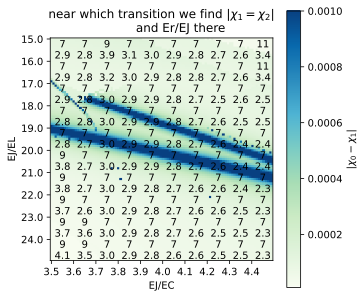

In [5]:
plt.figure(figsize=(5,5))
cmap = plt.cm.get_cmap('GnBu')
im = plt.imshow(zero_one_diff_grid/100, cmap=cmap,vmax = 1e-3,vmin = 1e-5)

EroverEJ_trunc = np.trunc(Er_over_EJ_grid* 10) / 10
for i in range(100)[5::10]:
    for j in range(100)[5::10]:
        plt.text(i,j,str(int(closest_transition_grid[i,j]))+'\n'+str(EroverEJ_trunc[i,j]),ha='center',va='center')
plt.xticks(ticks = range(len(EJoverEC_list))[::10],labels = np.trunc(EJoverEC_list[::10] * 10) / 10  )
plt.yticks(ticks = range(len(EJoverEL_list))[::10],labels =  np.trunc(EJoverEL_list[::10] * 10) / 10 )


cbar = plt.colorbar(im)
cbar.set_label(r'$|\chi_0-\chi_1|$')
plt.xlabel(rf'EJ/EC')
plt.ylabel(rf'EJ/EL')
plt.title(r'''near which transition we find $|\chi_1=\chi_2|$
          and Er/EJ there''')

plt.savefig('fig01_where_to_find_good_params_fine_grid.pdf', format='pdf', bbox_inches='tight')


In [8]:
EJoverEC_list[49]

3.994949494949495

(18.0, 21.0)

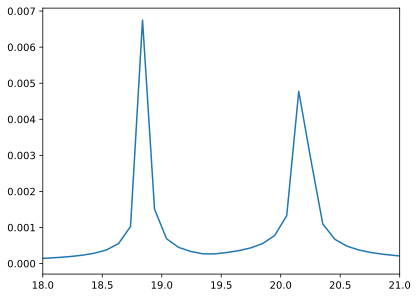

In [13]:
plt.plot(EJoverEL_list, zero_one_diff_grid[:,50]/100)
plt.xlim(18,21)

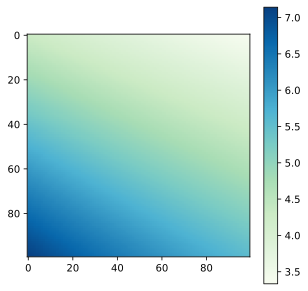

In [7]:
ratio_grid = np.empty((len(EJoverEL_list), len(EJoverEC_list)))


for i, EJoverEL in enumerate(EJoverEL_list):
    for j, EJoverEC in  enumerate(EJoverEC_list):
        ratio_grid[i,j] =EJoverEL/ EJoverEC

plt.figure(figsize=(5,5))
cmap = plt.cm.get_cmap('GnBu')
im = plt.imshow(ratio_grid, cmap=cmap)
cbar = plt.colorbar(im)